In [7]:
from rnn_from_scratch import *
from builder_rnn_keras import *

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, zipfile, shutil, json, re, time, random, math
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction, sentence_bleu
    from nltk.translate.meteor_score import meteor_score
    HAS_NLTK = True
except Exception as e:
    HAS_NLTK = False
    print("NLTK belum tersedia, METEOR akan pakai fallback sederhana:", e)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Set path dataset

In [18]:
from pathlib import Path

BASE_DIR = Path("../../")
DATASET_DIR = BASE_DIR / "data" / "rnn & lstm"

IMAGE_DIR = DATASET_DIR / "Images"
CAPTION_FILE = DATASET_DIR / "captions.txt"

print(IMAGES_DIR)
print(CAPTION_FILE)

ARTIFACT_DIR = Path("artifacts_rnn")
FEATURE_DIR = ARTIFACT_DIR / "features"
MODEL_DIR = ARTIFACT_DIR / "models"
RESULT_DIR = ARTIFACT_DIR / "results"

for d in [ARTIFACT_DIR, FEATURE_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

..\..\data\rnn & lstm\Images
..\..\data\rnn & lstm\captions.txt


## 2. Load dan cek captions.txt

In [19]:
captions_df = pd.read_csv(CAPTION_FILE)
captions_df.columns = [c.strip().lower() for c in captions_df.columns]

# Kaggle biasanya kolomnya: image, caption
print(captions_df.head())
print(captions_df.shape)
print(captions_df.columns)

assert "image" in captions_df.columns and "caption" in captions_df.columns

captions_df["image"] = captions_df["image"].astype(str).str.strip()
captions_df["caption"] = captions_df["caption"].astype(str).str.strip()

# Hanya pakai image yang filenya benar-benar ada
available_images = set(p.name for p in IMAGE_DIR.glob("*.jpg"))
captions_df = captions_df[captions_df["image"].isin(available_images)].reset_index(drop=True)

print("Jumlah caption setelah filter:", len(captions_df))
print("Jumlah unique image:", captions_df["image"].nunique())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
(40455, 2)
Index(['image', 'caption'], dtype='object')
Jumlah caption setelah filter: 40455
Jumlah unique image: 8091


## 3. Split image 6000 / 1000 / 1000

In [20]:
unique_images = sorted(captions_df["image"].unique())
random.Random(SEED).shuffle(unique_images)

train_imgs = set(unique_images[:6000])
val_imgs = set(unique_images[6000:7000])
test_imgs = set(unique_images[7000:8000])

# Kalau image total 8092, 92 sisanya tidak dipakai agar sesuai spesifikasi 6000/1000/1000.
print(len(train_imgs), len(val_imgs), len(test_imgs))

train_df = captions_df[captions_df["image"].isin(train_imgs)].reset_index(drop=True)
val_df = captions_df[captions_df["image"].isin(val_imgs)].reset_index(drop=True)
test_df = captions_df[captions_df["image"].isin(test_imgs)].reset_index(drop=True)

print("train captions:", train_df.shape)
print("val captions:", val_df.shape)
print("test captions:", test_df.shape)

6000 1000 1000
train captions: (30000, 2)
val captions: (5000, 2)
test captions: (5000, 2)


## 4. Preprocessing caption dan vocabulary

In [21]:
PAD_TOKEN = "<pad>"
START_TOKEN = "<start>"
END_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

def clean_caption(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^a-z\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

train_df["clean_caption"] = train_df["caption"].apply(clean_caption)
val_df["clean_caption"] = val_df["caption"].apply(clean_caption)
test_df["clean_caption"] = test_df["caption"].apply(clean_caption)

# Build vocab dari TRAIN saja
word_freq = {}
for cap in train_df["clean_caption"]:
    for w in cap.split():
        word_freq[w] = word_freq.get(w, 0) + 1

MIN_FREQ = 3
vocab_words = [w for w, f in word_freq.items() if f >= MIN_FREQ]
vocab_words = sorted(vocab_words)

idx_to_word = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN] + vocab_words
word_to_idx = {w: i for i, w in enumerate(idx_to_word)}

PAD_ID = word_to_idx[PAD_TOKEN]
START_ID = word_to_idx[START_TOKEN]
END_ID = word_to_idx[END_TOKEN]
UNK_ID = word_to_idx[UNK_TOKEN]

VOCAB_SIZE = len(word_to_idx)
print("VOCAB_SIZE:", VOCAB_SIZE)

# max length termasuk <start> dan <end>, ambil percentile agar tidak terlalu panjang
lengths = train_df["clean_caption"].apply(lambda x: len(x.split()) + 2)
MAX_SEQ_LEN = int(np.percentile(lengths, 95))
MAX_SEQ_LEN = max(MAX_SEQ_LEN, 8)

# token input panjangnya MAX_SEQ_LEN - 1, output model panjangnya MAX_SEQ_LEN karena ditambah feature timestep
MAX_INPUT_LEN = MAX_SEQ_LEN - 1
print("MAX_SEQ_LEN target:", MAX_SEQ_LEN)
print("MAX_INPUT_LEN caption tokens:", MAX_INPUT_LEN)

with open(ARTIFACT_DIR / "word_to_idx.json", "w") as f:
    json.dump(word_to_idx, f)
with open(ARTIFACT_DIR / "idx_to_word.json", "w") as f:
    json.dump({str(i): w for i, w in enumerate(idx_to_word)}, f)

VOCAB_SIZE: 3520
MAX_SEQ_LEN target: 20
MAX_INPUT_LEN caption tokens: 19


In [22]:
def encode_caption_for_preinject(clean_text: str):
    words = clean_text.split()
    ids = [word_to_idx.get(w, UNK_ID) for w in words]

    # full sequence: <start> w1 w2 ... wk <end>
    full = [START_ID] + ids + [END_ID]

    # input ke embedding: <start> w1 ... w_{k}; dipotong/pad ke MAX_INPUT_LEN
    input_ids = full[:-1][:MAX_INPUT_LEN]
    input_ids = input_ids + [PAD_ID] * (MAX_INPUT_LEN - len(input_ids))

    # target output sejajar dengan output model:
    # output timestep 0 = setelah feature CNN, target = kata pertama
    # output timestep 1 = setelah <start>, target = kata kedua, dst.
    target_ids = full[1:][:MAX_SEQ_LEN]
    target_ids = target_ids + [PAD_ID] * (MAX_SEQ_LEN - len(target_ids))

    return np.array(input_ids, dtype=np.int32), np.array(target_ids, dtype=np.int32)

sample_inp, sample_tgt = encode_caption_for_preinject(train_df.loc[0, "clean_caption"])
print(sample_inp.shape, sample_tgt.shape)
print(sample_inp[:10])
print(sample_tgt[:10])

(19,) (20,)
[   1    4  578 1514    4 2205  913 1550  621 3315]
[   4  578 1514    4 2205  913 1550  621 3315    4]


## 5. Feature extraction CNN encoder frozen

Dipakai InceptionV3 tanpa classification head (`include_top=False`, `pooling='avg'`) sehingga feature vector berdimensi 2048.
Proses ini cukup sekali. Kalau file `flickr8k_inception_features.npy` sudah ada, cell ini akan langsung load.

In [23]:
FEATURE_PATH = FEATURE_DIR / "flickr8k_inception_features.npy"
FEATURE_DIM = 2048
IMG_SIZE = (299, 299)

def load_and_preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr

def extract_features_inception(image_names, batch_size=64):
    encoder = InceptionV3(include_top=False, weights="imagenet", pooling="avg")
    encoder.trainable = False

    features = {}
    image_names = list(image_names)

    for start in range(0, len(image_names), batch_size):
        batch_names = image_names[start:start+batch_size]
        batch_arr = np.vstack([load_and_preprocess_image(IMAGE_DIR / name) for name in batch_names])
        batch_feat = encoder.predict(batch_arr, verbose=0)

        for name, feat in zip(batch_names, batch_feat):
            features[name] = feat.astype(np.float32)

        if start % (batch_size * 10) == 0:
            print(f"Extracted {start + len(batch_names)} / {len(image_names)}")

    return features

if FEATURE_PATH.exists():
    features = np.load(FEATURE_PATH, allow_pickle=True).item()
    print("Loaded features:", len(features))
else:
    all_used_imgs = sorted(list(train_imgs | val_imgs | test_imgs))
    features = extract_features_inception(all_used_imgs, batch_size=64)
    np.save(FEATURE_PATH, features)
    print("Saved:", FEATURE_PATH)

FEATURE_DIM = len(next(iter(features.values())))
print("FEATURE_DIM:", FEATURE_DIM)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 56s 1us/step
Extracted 64 / 8000
Extracted 704 / 8000
Extracted 1344 / 8000
Extracted 1984 / 8000
Extracted 2624 / 8000
Extracted 3264 / 8000
Extracted 3904 / 8000
Extracted 4544 / 8000
Extracted 5184 / 8000
Extracted 5824 / 8000
Extracted 6464 / 8000
Extracted 7104 / 8000
Extracted 7744 / 8000
Saved: artifacts_rnn\features\flickr8k_inception_features.npy
FEATURE_DIM: 2048


## 6. Build array training/validation/test

In [24]:
def build_arrays(df):
    n = len(df)
    X_feat = np.zeros((n, FEATURE_DIM), dtype=np.float32)
    X_tok = np.zeros((n, MAX_INPUT_LEN), dtype=np.int32)
    y = np.zeros((n, MAX_SEQ_LEN), dtype=np.int32)

    for i, row in enumerate(df.itertuples(index=False)):
        image_name = row.image
        clean_text = row.clean_caption
        inp, tgt = encode_caption_for_preinject(clean_text)
        X_feat[i] = features[image_name]
        X_tok[i] = inp
        y[i] = tgt

    sample_weight = (y != PAD_ID).astype(np.float32)
    return X_feat, X_tok, y, sample_weight

X_train_feat, X_train_tok, y_train, sw_train = build_arrays(train_df)
X_val_feat, X_val_tok, y_val, sw_val = build_arrays(val_df)
X_test_feat, X_test_tok, y_test, sw_test = build_arrays(test_df)

print(X_train_feat.shape, X_train_tok.shape, y_train.shape, sw_train.shape)
print(X_val_feat.shape, X_val_tok.shape, y_val.shape)
print(X_test_feat.shape, X_test_tok.shape, y_test.shape)

(30000, 2048) (30000, 19) (30000, 20) (30000, 20)
(5000, 2048) (5000, 19) (5000, 20)
(5000, 2048) (5000, 19) (5000, 20)


## 7. Build model Keras SimpleRNN pre-inject

In [25]:
def build_keras_rnn_decoder(
    feature_dim: int,
    vocab_size: int,
    max_input_len: int,
    embed_dim: int = 256,
    hidden_size: int = 256,
    num_rnn_layers: int = 1,
    learning_rate: float = 1e-3,
):
    image_feature_input = layers.Input(shape=(feature_dim,), name="image_feature_input")
    caption_token_input = layers.Input(shape=(max_input_len,), name="caption_token_input")

    # x_-1 = Dense(CNN_feature)
    feature_embed = layers.Dense(embed_dim, name="feature_projection")(image_feature_input)
    feature_embed = layers.Reshape((1, embed_dim), name="feature_as_timestep")(feature_embed)

    # x_t = W_emb token
    caption_embed = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        mask_zero=False,
        name="caption_embedding"
    )(caption_token_input)

    # [CNN_feature_projected, emb(<start>), emb(w1), ...]
    x = layers.Concatenate(axis=1, name="preinject_concat")([feature_embed, caption_embed])

    for i in range(num_rnn_layers):
        x = layers.SimpleRNN(
            hidden_size,
            activation="tanh",
            return_sequences=True,
            name=f"rnn_{i+1}"
        )(x)

    output = layers.Dense(vocab_size, activation="softmax", name="vocab_output")(x)

    model = Model(
        inputs=[image_feature_input, caption_token_input],
        outputs=output,
        name=f"rnn_decoder_{num_rnn_layers}layer_{hidden_size}hidden"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        weighted_metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    )
    return model

test_model = build_keras_rnn_decoder(FEATURE_DIM, VOCAB_SIZE, MAX_INPUT_LEN)
test_model.summary()

Model: "rnn_decoder_1layer_256hidden"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_feature_input │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 256)       │    524,544 │ image_feature_in… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_token_input │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_as_timestep │ (None, 1, 256)    │          0 │ feature_projecti… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_embedding   │ (None, 19, 256)   │    901,120 │ caption_token_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preinject_concat    │ (None, 20, 256)   │          0 │ feature_as_times… │
│ (Concatenate)       │                   │            │ caption_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_1 (SimpleRNN)   │ (None, 20, 256)   │    131,328 │ preinject_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vocab_output        │ (None, 20, 3520)  │    904,640 │ rnn_1[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,461,632 (9.39 MB)

 Trainable params: 2,461,632 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Training variasi RNN

In [27]:
EPOCHS = 10          # boleh dinaikkan: 15-30
BATCH_SIZE = 64
EMBED_DIM = 256

experiments = []
for num_layers in [1, 2, 3]:
    for hidden_size in [128, 512]:
        experiments.append({
            "name": f"rnn_{num_layers}layer_{hidden_size}hidden",
            "num_layers": num_layers,
            "hidden_size": hidden_size,
        })

all_histories = {}
training_summary = []

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

for exp in experiments:
    print("\n===== Training", exp["name"], "=====")
    model = build_keras_rnn_decoder(
        feature_dim=FEATURE_DIM,
        vocab_size=VOCAB_SIZE,
        max_input_len=MAX_INPUT_LEN,
        embed_dim=EMBED_DIM,
        hidden_size=exp["hidden_size"],
        num_rnn_layers=exp["num_layers"],
        learning_rate=1e-3,
    )

    start_time = time.time()
    history = model.fit(
        [X_train_feat, X_train_tok],
        y_train,
        sample_weight=sw_train,
        validation_data=([X_val_feat, X_val_tok], y_val, sw_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed = time.time() - start_time

    save_path = MODEL_DIR / f"{exp['name']}.keras"
    model.save(save_path)

    all_histories[exp["name"]] = history.history
    training_summary.append({
        **exp,
        "train_time_sec": elapsed,
        "best_val_loss": min(history.history["val_loss"]),
        "model_path": str(save_path),
    })

    with open(RESULT_DIR / "rnn_histories.json", "w") as f:
        json.dump(all_histories, f, indent=2)

training_summary_df = pd.DataFrame(training_summary)
training_summary_df.to_csv(RESULT_DIR / "rnn_training_summary.csv", index=False)
training_summary_df


===== Training rnn_1layer_128hidden =====
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 96ms/step - acc: 0.2027 - loss: 2.8307 - val_acc: 0.2312 - val_loss: 2.5763
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - acc: 0.2437 - loss: 2.5042 - val_acc: 0.2400 - val_loss: 2.4615
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - acc: 0.2604 - loss: 2.3906 - val_acc: 0.2556 - val_loss: 2.3794
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - acc: 0.2696 - loss: 2.3072 - val_acc: 0.2606 - val_loss: 2.3398
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - acc: 0.2755 - loss: 2.2489 - val_acc: 0.2633 - val_loss: 2.3087
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - acc: 0.2811 - loss: 2.2012 - val_acc: 0.2671 - val_loss: 2.2869
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - acc: 0.2855 - loss: 2.1608 - val_acc: 0.2697 - val_loss: 2.2747
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - acc: 0.2894 - loss: 2.1282 - val_acc: 0.2693 - val_loss: 2.26

,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path
0,rnn_1layer_128hidden,1,128,444.404358,2.250340,artifacts_rnn\models\rnn_1layer_128hidden.keras
1,rnn_1layer_512hidden,1,512,318.588647,2.271675,artifacts_rnn\models\rnn_1layer_512hidden.keras
2,rnn_2layer_128hidden,2,128,139.854820,2.388385,artifacts_rnn\models\rnn_2layer_128hidden.keras
3,rnn_2layer_512hidden,2,512,370.002378,2.412492,artifacts_rnn\models\rnn_2layer_512hidden.keras
4,rnn_3layer_128hidden,3,128,146.919511,2.420188,artifacts_rnn\models\rnn_3layer_128hidden.keras
5,rnn_3layer_512hidden,3,512,447.724923,2.383107,artifacts_rnn\models\rnn_3layer_512hidden.keras


## 9. Plot training loss dan validation loss

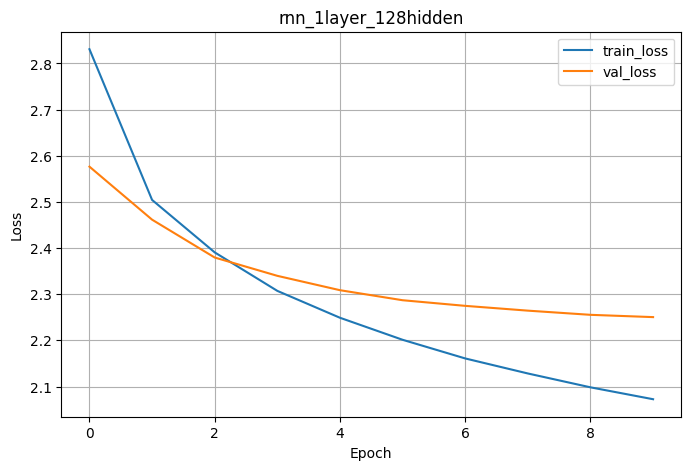

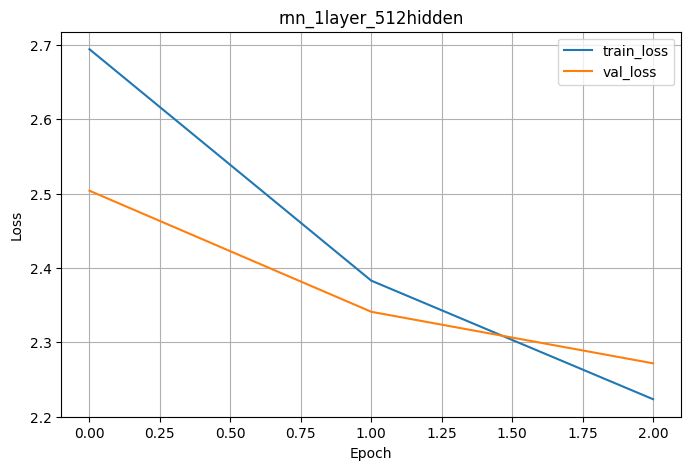

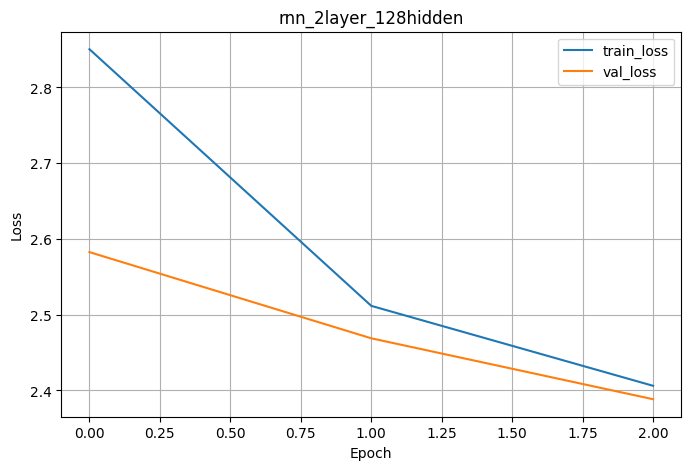

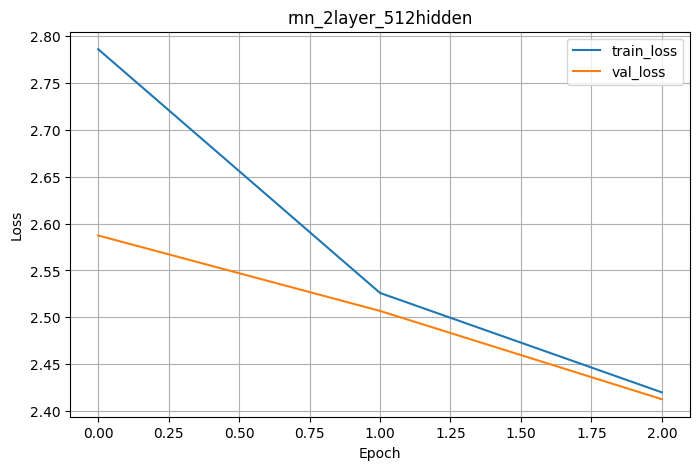

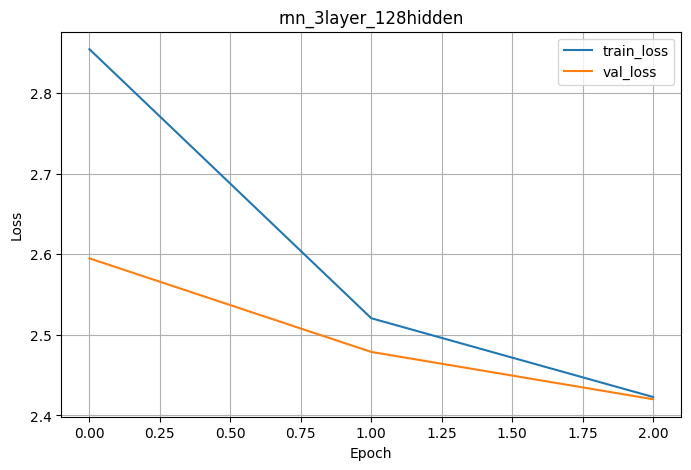

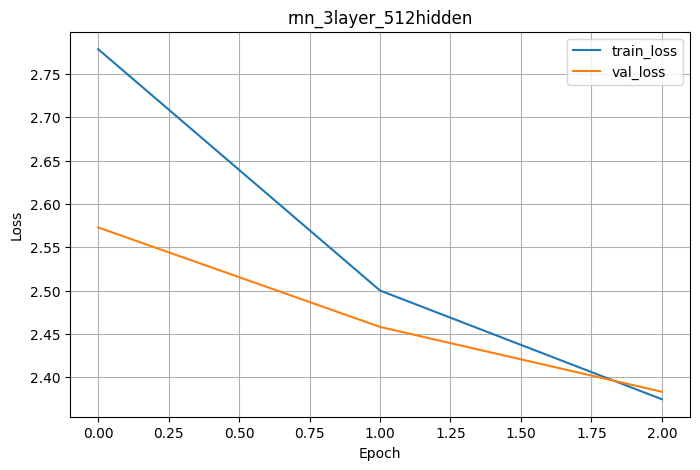

In [28]:
def plot_history(history_dict, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="train_loss")
    plt.plot(history_dict["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

for name, hist in all_histories.items():
    plot_history(hist, name)

## 10. Greedy decoding Keras

In [29]:
idx_to_word_dict = {i: w for i, w in enumerate(idx_to_word)}
word_to_idx_dict = word_to_idx

def ids_to_sentence(ids):
    words = []
    for idx in ids:
        idx = int(idx)
        w = idx_to_word_dict.get(idx, UNK_TOKEN)
        if w in [PAD_TOKEN, START_TOKEN]:
            continue
        if w == END_TOKEN:
            break
        words.append(w)
    return " ".join(words)

def generate_caption_keras(model, image_feature, max_caption_len=20):
    tokens = [START_ID]

    for _ in range(max_caption_len):
        inp = tokens[-MAX_INPUT_LEN:]
        inp = inp + [PAD_ID] * (MAX_INPUT_LEN - len(inp))
        inp = np.array(inp, dtype=np.int32)[None, :]

        feat = image_feature.astype(np.float32)[None, :]
        probs = model.predict([feat, inp], verbose=0)

        # Ambil timestep terakhir sesuai panjang token yang sudah masuk.
        # Karena output timestep 0 adalah feature, output timestep len(tokens)-1 memprediksi token berikutnya
        t = min(len(tokens) - 1, probs.shape[1] - 1)
        next_prob = probs[0, t, :].copy()
        next_prob[PAD_ID] = -1.0
        next_id = int(np.argmax(next_prob))

        if next_id == END_ID:
            break

        tokens.append(next_id)

    return ids_to_sentence(tokens[1:])

# Coba load model terbaik berdasarkan val loss
summary_df = pd.read_csv(RESULT_DIR / "rnn_training_summary.csv")
best_row = summary_df.sort_values("best_val_loss").iloc[0]
best_model_path = best_row["model_path"]
best_keras_model = tf.keras.models.load_model(best_model_path)

print("Best model:", best_row.to_dict())

sample_image = test_df.iloc[0]["image"]
print("Image:", sample_image)
print("Generated:", generate_caption_keras(best_keras_model, features[sample_image], max_caption_len=20))
print("Ground truth:")
print(test_df[test_df["image"] == sample_image]["caption"].tolist())

Best model: {'name': 'rnn_1layer_128hidden', 'num_layers': 1, 'hidden_size': 128, 'train_time_sec': 444.40435767173767, 'best_val_loss': 2.25033974647522, 'model_path': 'artifacts_rnn\\models\\rnn_1layer_128hidden.keras'}
Image: 1003163366_44323f5815.jpg
Generated: a little in in is is a a in in of
Ground truth:
['A man lays on a bench while his dog sits by him .', 'A man lays on the bench to which a white dog is also tied .', 'a man sleeping on a bench outside with a white and black dog sitting next to him .', 'A shirtless man lies on a park bench with his dog .', 'man laying on bench holding leash of dog sitting on ground']


## 11. Evaluasi BLEU-4 dan METEOR

In [30]:
def get_references_for_image(df, image_name):
    refs = []
    for cap in df[df["image"] == image_name]["clean_caption"]:
        refs.append(cap.split())
    return refs

def meteor_fallback(references, hypothesis):
    # Fallback sederhana kalau NLTK meteor tidak tersedia.
    # Bukan METEOR resmi, tapi bisa dipakai sementara agar notebook tetap jalan.
    hyp = set(hypothesis)
    if len(hyp) == 0:
        return 0.0
    scores = []
    for ref in references:
        ref_set = set(ref)
        precision = len(hyp & ref_set) / max(len(hyp), 1)
        recall = len(hyp & ref_set) / max(len(ref_set), 1)
        if precision + recall == 0:
            scores.append(0.0)
        else:
            scores.append((10 * precision * recall) / (recall + 9 * precision))
    return max(scores) if scores else 0.0

def evaluate_caption_model_keras(model, df_eval, max_images=1000, max_caption_len=20):
    eval_images = sorted(df_eval["image"].unique())[:max_images]

    references_all = []
    hypotheses_all = []
    meteor_scores = []

    start = time.time()
    for name in eval_images:
        pred = generate_caption_keras(model, features[name], max_caption_len=max_caption_len)
        hyp = pred.split()
        refs = get_references_for_image(df_eval, name)

        references_all.append(refs)
        hypotheses_all.append(hyp)

        if HAS_NLTK:
            try:
                meteor_scores.append(meteor_score(refs, hyp))
            except Exception:
                meteor_scores.append(meteor_fallback(refs, hyp))
        else:
            meteor_scores.append(meteor_fallback(refs, hyp))

    elapsed = time.time() - start
    smoothie = SmoothingFunction().method4 if HAS_NLTK else None

    if HAS_NLTK:
        bleu4 = corpus_bleu(
            references_all,
            hypotheses_all,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothie
        )
    else:
        bleu4 = np.nan

    return {
        "BLEU_4": bleu4,
        "METEOR": float(np.mean(meteor_scores)),
        "time_sec": elapsed,
        "n_images": len(eval_images),
    }

eval_rows = []
for _, row in summary_df.iterrows():
    print("Evaluating:", row["name"])
    model = tf.keras.models.load_model(row["model_path"])
    metrics = evaluate_caption_model_keras(model, test_df, max_images=1000, max_caption_len=20)
    eval_rows.append({**row.to_dict(), **metrics})

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(RESULT_DIR / "rnn_test_metrics_keras.csv", index=False)
eval_df.sort_values(["BLEU_4", "METEOR"], ascending=False)

Evaluating: rnn_1layer_128hidden
Evaluating: rnn_1layer_512hidden
Evaluating: rnn_2layer_128hidden
Evaluating: rnn_2layer_512hidden
Evaluating: rnn_3layer_128hidden
Evaluating: rnn_3layer_512hidden


,name,num_layers,hidden_size,train_time_sec,best_val_loss,model_path,BLEU_4,METEOR,time_sec,n_images
2,rnn_2layer_128hidden,2,128,139.854820,2.388385,artifacts_rnn\models\rnn_2layer_128hidden.keras,0.085550,0.291923,1448.522631,1000
3,rnn_2layer_512hidden,2,512,370.002378,2.412492,artifacts_rnn\models\rnn_2layer_512hidden.keras,0.085550,0.291923,1581.953960,1000
4,rnn_3layer_128hidden,3,128,146.919511,2.420188,artifacts_rnn\models\rnn_3layer_128hidden.keras,0.085550,0.291923,1461.186404,1000
0,rnn_1layer_128hidden,1,128,444.404358,2.250340,artifacts_rnn\models\rnn_1layer_128hidden.keras,0.071980,0.343382,1603.727139,1000
1,rnn_1layer_512hidden,1,512,318.588647,2.271675,artifacts_rnn\models\rnn_1layer_512hidden.keras,0.063471,0.262039,1102.967968,1000
5,rnn_3layer_512hidden,3,512,447.724923,2.383107,artifacts_rnn\models\rnn_3layer_512hidden.keras,0.035646,0.311833,2361.101584,1000


## 12. Load bobot Keras ke RNN from scratch NumPy

In [31]:
from rnn_from_scratch import build_scratch_decoder_from_keras

best_row = eval_df.sort_values(["BLEU_4", "METEOR"], ascending=False).iloc[0]
best_model_path = best_row["model_path"]
best_keras_model = tf.keras.models.load_model(best_model_path)

num_layers = int(best_row["num_layers"])
layer_names = {
    "feature_projection": "feature_projection",
    "embedding": "caption_embedding",
    "rnn_layers": [f"rnn_{i+1}" for i in range(num_layers)],
    "output_dense": "vocab_output",
}

scratch_decoder = build_scratch_decoder_from_keras(
    best_keras_model,
    layer_names=layer_names,
    idx_to_word=idx_to_word_dict,
    word_to_idx=word_to_idx_dict,
)

print("Scratch decoder berhasil dibuat dari:", best_model_path)

Scratch decoder berhasil dibuat dari: artifacts_rnn\models\rnn_2layer_128hidden.keras


In [32]:
def generate_caption_scratch(decoder, image_feature, max_caption_len=20):
    return decoder.generate_caption(
        image_feature=image_feature.astype(np.float32),
        start_id=START_ID,
        end_id=END_ID,
        max_len=max_caption_len,
        pad_id=PAD_ID,
    )

sample_image = test_df.iloc[0]["image"]
print("Keras  :", generate_caption_keras(best_keras_model, features[sample_image], max_caption_len=20))
print("Scratch:", generate_caption_scratch(scratch_decoder, features[sample_image], max_caption_len=20))

Keras  : a man in a red shirt is a a
Scratch: man a and is in red is a


## 13. Evaluasi Scratch

In [33]:
def evaluate_caption_model_scratch(decoder, df_eval, max_images=1000, max_caption_len=20):
    eval_images = sorted(df_eval["image"].unique())[:max_images]

    references_all = []
    hypotheses_all = []
    meteor_scores = []

    start = time.time()
    for name in eval_images:
        pred = generate_caption_scratch(decoder, features[name], max_caption_len=max_caption_len)
        hyp = pred.split()
        refs = get_references_for_image(df_eval, name)

        references_all.append(refs)
        hypotheses_all.append(hyp)

        if HAS_NLTK:
            try:
                meteor_scores.append(meteor_score(refs, hyp))
            except Exception:
                meteor_scores.append(meteor_fallback(refs, hyp))
        else:
            meteor_scores.append(meteor_fallback(refs, hyp))

    elapsed = time.time() - start

    if HAS_NLTK:
        bleu4 = corpus_bleu(
            references_all,
            hypotheses_all,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=SmoothingFunction().method4
        )
    else:
        bleu4 = np.nan

    return {
        "BLEU_4": bleu4,
        "METEOR": float(np.mean(meteor_scores)),
        "time_sec": elapsed,
        "n_images": len(eval_images),
    }

scratch_metrics = evaluate_caption_model_scratch(scratch_decoder, test_df, max_images=1000, max_caption_len=20)
keras_metrics = evaluate_caption_model_keras(best_keras_model, test_df, max_images=1000, max_caption_len=20)

comparison_df = pd.DataFrame([
    {"implementation": "Keras", **keras_metrics},
    {"implementation": "Scratch NumPy", **scratch_metrics},
])
comparison_df.to_csv(RESULT_DIR / "rnn_keras_vs_scratch.csv", index=False)
comparison_df

,implementation,BLEU_4,METEOR,time_sec,n_images
0,Keras,0.085550,0.291923,554.762316,1000
1,Scratch NumPy,0.005322,0.306650,7.970459,1000


## 14. Pengaruh panjang maksimum caption

In [34]:
max_len_rows = []
for max_len in [10, 20, 30]:
    print("max_caption_len:", max_len)
    metrics = evaluate_caption_model_scratch(
        scratch_decoder,
        test_df,
        max_images=1000,
        max_caption_len=max_len
    )
    max_len_rows.append({"max_caption_len": max_len, **metrics})

max_len_df = pd.DataFrame(max_len_rows)
max_len_df.to_csv(RESULT_DIR / "rnn_max_caption_len.csv", index=False)
max_len_df

max_caption_len: 10
max_caption_len: 20
max_caption_len: 30


,max_caption_len,BLEU_4,METEOR,time_sec,n_images
0,10,0.005322,0.30665,6.553416,1000
1,20,0.005322,0.30665,6.409423,1000
2,30,0.005322,0.30665,7.032557,1000


## 15. Qualitative analysis 10 contoh gambar

In [35]:
def sentence_bleu4(refs, hyp):
    if not HAS_NLTK:
        return np.nan
    return sentence_bleu(
        refs,
        hyp,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=SmoothingFunction().method4
    )

qual_rows = []
for name in sorted(test_df["image"].unique())[:200]:
    pred = generate_caption_scratch(scratch_decoder, features[name], max_caption_len=20)
    hyp = pred.split()
    refs = get_references_for_image(test_df, name)

    qual_rows.append({
        "image": name,
        "pred_caption_rnn": pred,
        "ground_truth": " | ".join(test_df[test_df["image"] == name]["caption"].tolist()),
        "sentence_bleu4": sentence_bleu4(refs, hyp)
    })

qual_df = pd.DataFrame(qual_rows).sort_values("sentence_bleu4", ascending=False)

# ambil contoh score tinggi, sedang, rendah
top = qual_df.head(4)
mid = qual_df.iloc[len(qual_df)//2:len(qual_df)//2+3]
low = qual_df.tail(3)
qual_sample_df = pd.concat([top, mid, low]).reset_index(drop=True)

qual_sample_df.to_csv(RESULT_DIR / "rnn_qualitative_examples.csv", index=False)
qual_sample_df

,image,pred_caption_rnn,ground_truth,sentence_bleu4
0,1507563902_6ec8d5d822.jpg,man a and is in red is a,a child is doing a back flip whilst jumping on...,0.196316
1,2245618207_fa486ba2b7.jpg,man a and is in red is a,A child in red jumps on a red object while oth...,0.111477
2,181415975_2627aa6668.jpg,man a and is in red is a,A blonde man is wakeboarding and is jumping in...,0.097423
3,2338627102_6708a9b4fd.jpg,man a and is in red is a,A man in a red jacket and khaki pants is walki...,0.097423
4,159712188_d530dd478c.jpg,man a and is in red is a,A woman is walking past an artificial waterfal...,0.040446
5,1897025969_0c41688fa6.jpg,man a and is in red is a,A black dog and a tan dog fighting . | A black...,0.040446
6,1563731247_7f21d8bec0.jpg,man a and is in red is a,A child plays on the ground in a pile of leave...,0.040446
7,2303356248_65dd6aba6f.jpg,man a and is in red is a,Kids wearing jackets and hats swinging on tire...,0.027798
8,1295669416_21cabf594d.jpg,man a and is in red is a,A girl dressed in a red and black top with bla...,0.027149
9,1262454669_f1caafec2d.jpg,man a and is in red is a,A girl in a white shirt is sitting on a park b...,0.017828


Image: 1507563902_6ec8d5d822.jpg
BLEU-4: 0.19631553595781936
RNN prediction: man a and is in red is a
Ground truth: a child is doing a back flip whilst jumping on a trampoline . | A girl is doing a trick on a blue trampoline and is in the air . | An upside-down child above a trampoline . | A person is upside down in the air above a trampoline outside . | Someone is flipping on a blue trampoline .


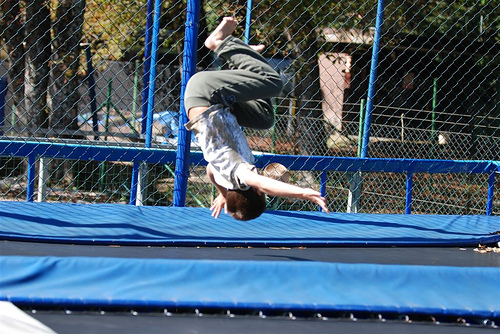

Image: 2245618207_fa486ba2b7.jpg
BLEU-4: 0.11147663481766389
RNN prediction: man a and is in red is a
Ground truth: A child in red jumps on a red object while others laugh . | A child touching a red plastic object , with a crowd behind him . | A girl in a crowd laughs and climbs on something . | Many children having fun outside near large buildings . | There is a girl in a red jacket smiling with her hand on a red blowup and a crowd behind her .


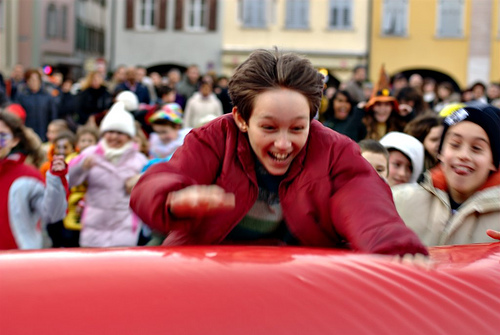

Image: 181415975_2627aa6668.jpg
BLEU-4: 0.09742334762055092
RNN prediction: man a and is in red is a
Ground truth: A blonde man is wakeboarding and is jumping into the air . | a blond man jumping through the air over the ocean | A blond man on a single waterski . | A man gets air time on his wakeboard . | Man airborne on wakeboard with elevation in the background and blue water .


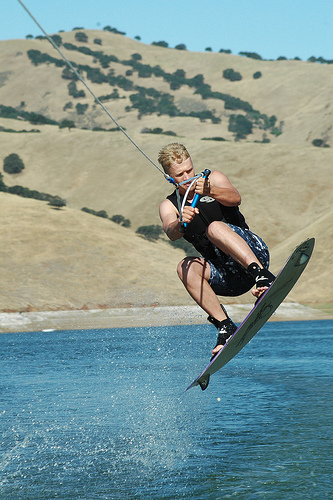

Image: 2338627102_6708a9b4fd.jpg
BLEU-4: 0.09742334762055092
RNN prediction: man a and is in red is a
Ground truth: A man in a red jacket and khaki pants is walking through a part of what looks like Arizona . | A man wearing jeans and a hooded , long sleeved top , and a backpack , walks in a desert . | A person with a red hooded jacket and a black backpack is walking near a rocky wall . | Man wearing red looks on at desert | There is a lone hiker in the middle of a prairie with his back to the camera , showing his backpack .


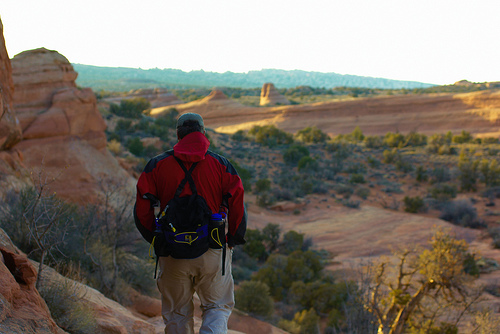

Image: 159712188_d530dd478c.jpg
BLEU-4: 0.040445966468773985
RNN prediction: man a and is in red is a
Ground truth: A woman is walking past an artificial waterfall . | A woman is walking with someone else beside a pond in the city . | A woman talking on a cellphone walking in front of water . | A woman walks by a river across city buildings . | Young woman in a city park near a water feature .


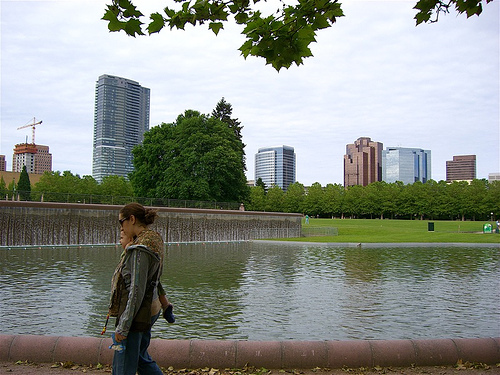

Image: 1897025969_0c41688fa6.jpg
BLEU-4: 0.040445966468773985
RNN prediction: man a and is in red is a
Ground truth: A black dog and a tan dog fighting . | A black dog and a white dog are wrestling on the ground . | A black dog bites a white dog while standing on the sand . | two dogs fight . | Two dogs , one white and one black , play with each other in the sand .


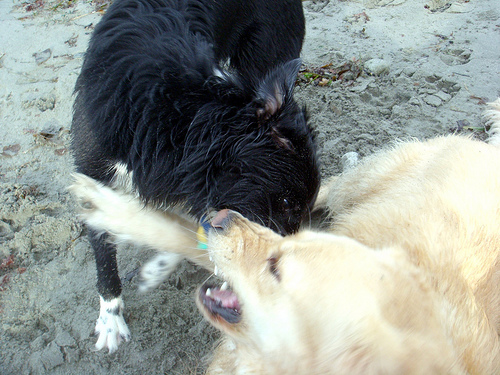

Image: 1563731247_7f21d8bec0.jpg
BLEU-4: 0.040445966468773985
RNN prediction: man a and is in red is a
Ground truth: A child plays on the ground in a pile of leaves . | a little girl is playing in the hay . | Little girl buried in hay throwing hay around at a lady . | The girls play in the pumpkin patch . | Two children are playing in a pile of hay with the sun shining overhead .


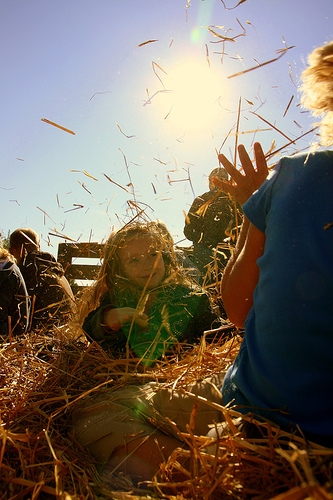

Image: 2303356248_65dd6aba6f.jpg
BLEU-4: 0.027798079124327517
RNN prediction: man a and is in red is a
Ground truth: Kids wearing jackets and hats swinging on tire swing in snow | Two children swing in a tire in the snow at a park . | Two children swing on a tire swing on a snowy day . | Two kids in snow hats and blue and green coats are swinging on a tire swing out in the snow . | Two young children are being pushed on a tire swing with snow on the ground .


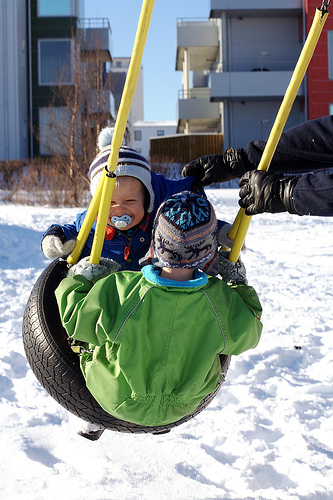

Image: 1295669416_21cabf594d.jpg
BLEU-4: 0.02714880957215405
RNN prediction: man a and is in red is a
Ground truth: A girl dressed in a red and black top with black pants is sitting on a wall . | A girl in a red and black striped shirt sits on a brick wall in front of a tropical plant . | A girl wearing a red and black striped shirt is sitting on a brick wall near a flower garden . | A lady in a red and black striped shirt is sitting on a retaining wall . | A woman in semi-formal attire is sitting on a concrete wall .


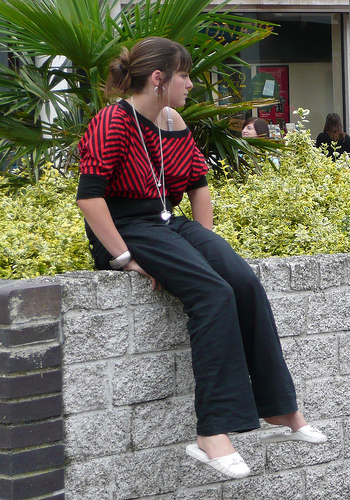

Image: 1262454669_f1caafec2d.jpg
BLEU-4: 0.017827688989800743
RNN prediction: man a and is in red is a
Ground truth: A girl in a white shirt is sitting on a park bench with a dog next to her . | A woman eats on a bench while a brown and white leashed dog stands next to her . | a woman is sitting on a bench with a latte in her lap and a white dog on a blue leash to her side . | A woman sits on a bench at the park with her dog in front of her . | Woman sitting on bench and holding the leash of a large white and brown dog .


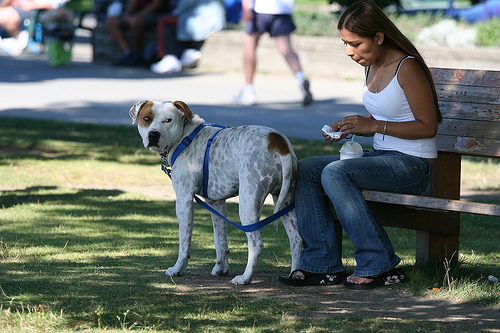

In [36]:
from IPython.display import display, Image as IPImage

for _, row in qual_sample_df.iterrows():
    print("=" * 80)
    print("Image:", row["image"])
    print("BLEU-4:", row["sentence_bleu4"])
    print("RNN prediction:", row["pred_caption_rnn"])
    print("Ground truth:", row["ground_truth"])
    display(IPImage(filename=str(IMAGE_DIR / row["image"]), width=300))